## Example: Vertical 1D column simulation

The setup of the vertical model can be accessed in `/setups/verticalcolumn/` directory. 

To visualise an example run done using the `/setups/verticalcolumn/` setup files.

Note: Radial drift is turned off in this simulation to keep the vertical column mass constant.

## Data visualisation

In [1]:
from mcdust import Simulation, Plots

In [2]:
sim = Simulation()

In [14]:
path='/your/path/to/data/directory'
sim.read(path)

 Reading paramters file from data files in /scratch/vaikundaraman/mcdust_1Dtest/outputs/vertical1D_v2/
mcdust   v1.0
Authors : Dr Joanna Drazkowska, Vignesh Vaikundaraman, Nerea Gurrutuxaga
Please cite Drążkowska, Windmark & Dullemond (2013) A&A 556, A37
Reading data ...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 37/37 [00:00<00:00, 675.56it/s]

Done!


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.stats import kde
from scipy.constants import golden
from astropy import units as u
from astropy import constants as c
import os as os
au = u.au.to(u.cm)
k_b = c.k_B.cgs.value
m_p = c.m_p.cgs.value
Grav = c.G.cgs.value
Msun = c.M_sun.cgs.value
a0=1.e-4
amax= np.max(sim.swarms.grain_size)

Text(0.5, 1.0, 't = 1000.2 years')

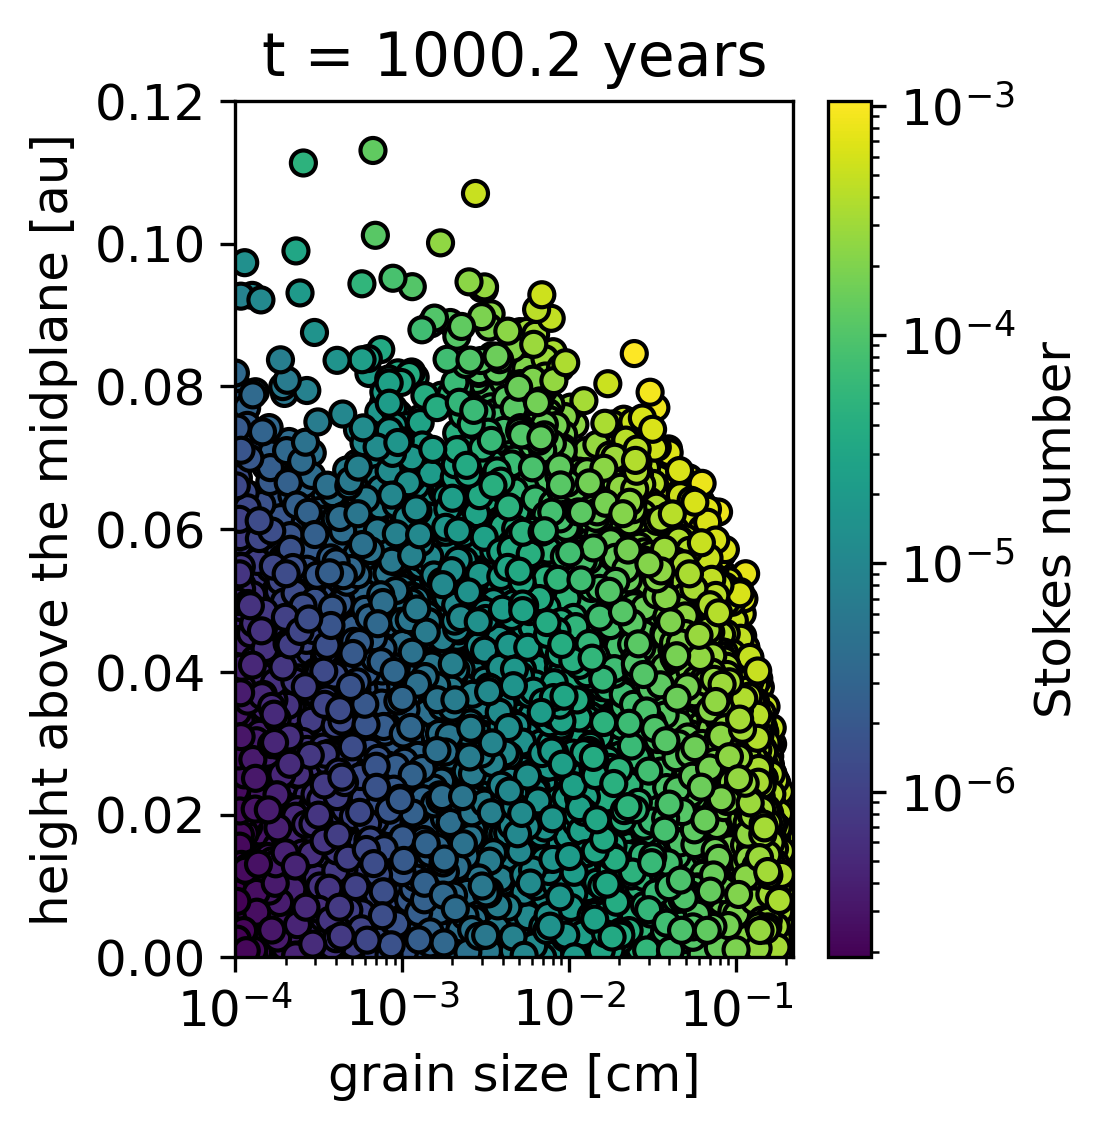

In [25]:
time = 1000. # years

it = sim.swarms.snapt.searchsorted(time)
dpi=300.
width = 6.
f,ax=plt.subplots(figsize=(width/2., width/golden),dpi=dpi)
ax.set_xscale("log")
ax.set_xlim(a0,amax)
ax.set_ylim(0,0.12)
im=ax.scatter(sim.swarms.grain_size[it,:],abs(sim.swarms.zdis[it,:]),c=sim.swarms.St[it,:],edgecolors='k',norm=LogNorm())
cbar=f.colorbar(im)
cbar.ax.set_ylabel("Stokes number")
ax.set_xlabel("grain size [cm]")
ax.set_ylabel("height above the midplane [au]")

ax.set_title('t = {:.1f} years'.format(sim.swarms.snapt[it]))#the argument step denotes the increment to print every nth variable. The default is 1.